<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #16a34a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Bosques Aleatorios (Random Forests) y Feature Importance 🌲🌲📊
      </h1>
      <p style="margin: 6px 0 0 0; color: #16a34a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Random Forests & Feature Importance
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #15803d; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #16a34a; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/04_Bosques_Aleatorios_Random_Forests.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El problema que dejó abierto el Bagging: árboles poco decorrelacionados 🌲🔗

El **Cuaderno 03** mostró que Bagging mejora sobre un árbol individual sin restricciones (test: 0.6928 → 0.7216) pero se estanca muy por debajo de la mejor poda del Cuaderno 02 (0.7584): los 50 árboles del ensamble coincidieron el **100% de las veces** en usar `tipo_contrato_ord` como variable de la raíz, y la correlación promedio entre las predicciones de pares de árboles fue **0.3073** — lejos de ser independientes. La razón es simple: aunque cada árbol ve una muestra bootstrap distinta, **CART sigue evaluando las 8 variables completas en cada división**, así que casi cualquier muestra prefiere la misma variable dominante en la raíz. Promediar árboles que cometen los mismos errores no cancela mucha varianza, sin importar cuántos se agreguen.

**Bosques Aleatorios** (*Random Forests*, Breiman 2001) resuelven esto con un cambio mínimo pero decisivo: además del muestreo bootstrap de Bagging, en **cada división de cada árbol** solo se le permite al algoritmo considerar un **subconjunto aleatorio** de $m$ variables (elegido de nuevo en cada división), en lugar de las $p$ variables completas. Cuando la variable dominante no está disponible en el subconjunto sorteado, el árbol se ve forzado a dividir sobre otra variable — más débil, pero distinta de un árbol a otro — lo que **decorrelaciona** el ensamble de una forma que el muestreo bootstrap por sí solo no logra. Para clasificación, el valor por defecto es $m = \sqrt{p}$; para regresión, $m = p/3$.

### 1.1 Preparación: recargando los datos y la partición de los Cuadernos 00–03

Se repite exactamente la misma codificación de variables y la misma partición train/test (`test_size=0.25`, `random_state=42`, estratificada por `churn`) usadas en el resto del módulo, para que los resultados de este cuaderno sean directamente comparables.

In [34]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "abandono_clientes_telecom.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_telecom = pd.read_csv(load_dataset("abandono_clientes_telecom.csv"))

df_prep = df_telecom.copy()
df_prep["factura_electronica"] = df_prep["factura_electronica"].map({"No": 0, "Si": 1})

orden_contrato = [["Mes_a_Mes", "Un_Ano", "Dos_Anos"]]
encoder_contrato = OrdinalEncoder(categories=orden_contrato)
df_prep["tipo_contrato_ord"] = encoder_contrato.fit_transform(df_prep[["tipo_contrato"]]).astype(int)

soporte_dummies = pd.get_dummies(df_prep["soporte_tecnico"], prefix="soporte").astype(int)
df_prep = pd.concat([df_prep, soporte_dummies], axis=1)

feature_cols = ["antiguedad_meses", "cargo_mensual", "cargos_totales",
                 "tipo_contrato_ord", "factura_electronica",
                 "soporte_No", "soporte_Si", "soporte_Sin_Internet"]

X = df_prep[feature_cols]
y = df_prep["churn"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

p = len(feature_cols)
m_sqrt = int(np.sqrt(p))
print(f"Filas de entrenamiento: {len(Xtr)}  |  Filas de prueba: {len(Xte)}")
print(f"Numero de atributos codificados p = {p}")
print(f"sqrt(p) = {np.sqrt(p):.4f}  ->  m = int(sqrt(p)) = {m_sqrt} atributos considerados por division con max_features='sqrt'")

Filas de entrenamiento: 1875  |  Filas de prueba: 625
Numero de atributos codificados p = 8
sqrt(p) = 2.8284  ->  m = int(sqrt(p)) = 2 atributos considerados por division con max_features='sqrt'


---
## 2. Ajustando el primer Bosque Aleatorio 🌲🌲🌲

Con $p=8$ variables codificadas, `max_features='sqrt'` restringe cada división a considerar solo $m = \text{int}(\sqrt{8}) = 2$ variables sorteadas al azar — una restricción fuerte: **1 de cada 4** variables disponibles en cada división, en lugar de las 8 completas que sigue usando Bagging. `RandomForestClassifier` implementa exactamente el procedimiento de la Sección 1: muestreo bootstrap (igual que `BaggingClassifier`) más este submuestreo aleatorio de atributos en cada división.

In [35]:
arbol_post_podado = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0017782004989982565).fit(Xtr, ytr)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50,
                             oob_score=True, random_state=42)
bagging.fit(Xtr, ytr)

rf = RandomForestClassifier(n_estimators=100, max_features="sqrt", oob_score=True, random_state=42)
rf.fit(Xtr, ytr)

print("Comparacion de exactitud (train / test / OOB):")
print(f"  Mejor podado, ccp_alpha=0.001778 (Cuaderno 02)     -> train={arbol_post_podado.score(Xtr, ytr):.4f}  test={arbol_post_podado.score(Xte, yte):.4f}")
print(f"  Bagging, 50 arboles sin podar (Cuaderno 03)        -> train={bagging.score(Xtr, ytr):.4f}  test={bagging.score(Xte, yte):.4f}  OOB={bagging.oob_score_:.4f}")
print(f"  Random Forest, 100 arboles, max_features='sqrt'    -> train={rf.score(Xtr, ytr):.4f}  test={rf.score(Xte, yte):.4f}  OOB={rf.oob_score_:.4f}")

Comparacion de exactitud (train / test / OOB):
  Mejor podado, ccp_alpha=0.001778 (Cuaderno 02)     -> train=0.7616  test=0.7584
  Bagging, 50 arboles sin podar (Cuaderno 03)        -> train=1.0000  test=0.7216  OOB=0.7136
  Random Forest, 100 arboles, max_features='sqrt'    -> train=1.0000  test=0.7152  OOB=0.7163


**Lectura honesta:** el Random Forest (test=**0.7152**, OOB=**0.7163**) **no supera** a Bagging en exactitud de prueba (0.7216) en esta partición concreta — de hecho queda ligeramente por debajo — aunque su OOB score sí mejora levemente (0.7163 frente a 0.7136). Y ninguno de los dos ensambles alcanza al árbol podado del Cuaderno 02 (0.7584). Esto **no** significa que la idea de la Sección 1 esté equivocada: significa que, en un dataset con solo $p=8$ variables y una variable claramente dominante (`tipo_contrato_ord`), restringir cada división a solo $m=2$ variables es una penalización fuerte — cada árbol individual del bosque se vuelve más débil (pierde acceso a la variable más informativa en más divisiones) y esa pérdida de fuerza individual puede compensar, o incluso superar, la ganancia por decorrelación. La Sección 3 verifica que la decorrelación sí ocurre como predice la teoría; la Sección 4 explora si un valor distinto de `max_features` recupera la ventaja.

---
## 3. Verificación empírica: ¿de verdad se decorrelacionan los árboles? 🔬

La Sección 6 del Cuaderno 03 midió dos síntomas concretos de la falta de decorrelación en Bagging: (1) el **100%** de los árboles usaban `tipo_contrato_ord` en la raíz, y (2) la correlación promedio entre las predicciones de pares de árboles era **0.3073**. Si la Sección 1 tiene razón, el submuestreo de atributos del Random Forest debería reducir ambos síntomas — sin necesariamente eliminarlos, porque el muestreo bootstrap por sí solo ya aporta algo de diversidad.

In [36]:
raices_rf = [feature_cols[est.tree_.feature[0]] for est in rf.estimators_]
print("Variable elegida en la raiz, en los 100 arboles del Random Forest:")
print(Counter(raices_rf))

preds_rf = np.array([est.predict(Xte.values) for est in rf.estimators_])
correlaciones_rf = np.corrcoef(preds_rf)
iu = np.triu_indices_from(correlaciones_rf, k=1)
print(f"\nCorrelacion promedio entre predicciones de pares de arboles (Random Forest): {correlaciones_rf[iu].mean():.4f}")
print(f"Correlacion promedio entre predicciones de pares de arboles (Bagging, Cuaderno 03): 0.3073")

Variable elegida en la raiz, en los 100 arboles del Random Forest:
Counter({'tipo_contrato_ord': 23, 'cargo_mensual': 22, 'antiguedad_meses': 18, 'cargos_totales': 17, 'factura_electronica': 8, 'soporte_No': 5, 'soporte_Sin_Internet': 4, 'soporte_Si': 3})

Correlacion promedio entre predicciones de pares de arboles (Random Forest): 0.2883
Correlacion promedio entre predicciones de pares de arboles (Bagging, Cuaderno 03): 0.3073


**Lectura:** la decorrelación sí ocurre, con números concretos. En Bagging, **el 100%** de los 50 árboles usaban `tipo_contrato_ord` en la raíz; en el Random Forest, esa variable aparece en la raíz de solo **23 de los 100 árboles** (23%) — el resto se reparte entre `cargo_mensual` (22), `antiguedad_meses` (18), `cargos_totales` (17) y las demás variables (20 en conjunto). La correlación promedio entre pares de árboles también baja, de **0.3073** (Bagging) a **0.2883** (Random Forest) — una reducción real, aunque modesta, porque con solo $p=8$ variables el submuestreo de atributos no genera tanta diversidad adicional como lo haría en un dataset con docenas de variables. Esto confirma el mecanismo exacto que predice la teoría de Bagging (Cuaderno 03, Sección 1): los árboles del Random Forest son menos redundantes entre sí. Que esa menor correlación no se haya traducido todavía en una mejor exactitud de prueba (Sección 2) es, precisamente, la pregunta que abre la Sección 4: ¿existe un valor de `max_features` que equilibre mejor la pérdida de fuerza individual de cada árbol con la ganancia por decorrelación?

---
## 4. El hiperparámetro `max_features`: barriendo el equilibrio 🎚️

`max_features` controla directamente cuántas variables $m$ se sortean en cada división. Valores pequeños maximizan la decorrelación (Sección 3) pero debilitan a cada árbol individual (Sección 2); valores grandes se acercan a Bagging (todas las variables disponibles, sin decorrelación adicional). Esta sección barre `'sqrt'` ($m=2$), `'log2'` ($m=3$), varios enteros fijos, y `None` (todas las $p=8$ variables — el caso equivalente a Bagging, salvo por el mecanismo interno de submuestreo de scikit-learn), registrando exactitud de prueba y OOB score de cada uno.

In [37]:
max_features_grid = ["sqrt", "log2", 1, 2, 3, 4, 6, 8, None]
test_accs_mf, oob_scores_mf, etiquetas_mf = [], [], []

for mf in max_features_grid:
    r = RandomForestClassifier(n_estimators=100, max_features=mf, oob_score=True, random_state=42)
    r.fit(Xtr, ytr)
    test_accs_mf.append(r.score(Xte, yte))
    oob_scores_mf.append(r.oob_score_)
    etiquetas_mf.append(str(mf))
    print(f"max_features={str(mf):<6}  test_acc={test_accs_mf[-1]:.4f}  oob_score={oob_scores_mf[-1]:.4f}")

max_features=sqrt    test_acc=0.7152  oob_score=0.7163
max_features=log2    test_acc=0.7136  oob_score=0.7189
max_features=1       test_acc=0.6928  oob_score=0.7045
max_features=2       test_acc=0.7152  oob_score=0.7163
max_features=3       test_acc=0.7136  oob_score=0.7189
max_features=4       test_acc=0.7232  oob_score=0.7248
max_features=6       test_acc=0.7264  oob_score=0.7285
max_features=8       test_acc=0.7328  oob_score=0.7248
max_features=None    test_acc=0.7328  oob_score=0.7248


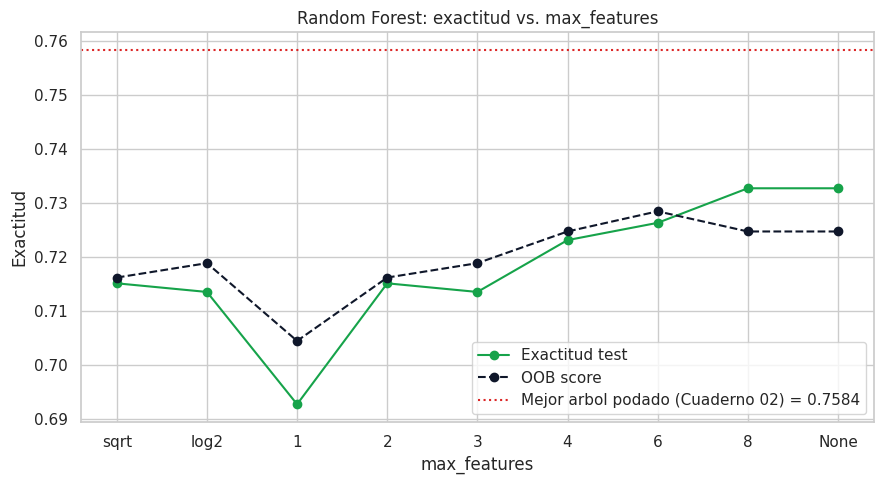

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(max_features_grid))
ax.plot(x_pos, test_accs_mf, marker="o", label="Exactitud test", color="#16a34a")
ax.plot(x_pos, oob_scores_mf, marker="o", label="OOB score", color="#0f172a", linestyle="--")
ax.axhline(0.7584, color="#dc2626", linestyle=":", label="Mejor arbol podado (Cuaderno 02) = 0.7584")
ax.set_xticks(x_pos)
ax.set_xticklabels(etiquetas_mf)
ax.set_xlabel("max_features")
ax.set_ylabel("Exactitud")
ax.set_title("Random Forest: exactitud vs. max_features")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura honesta:** en este dataset, el patrón **no** es el que suele mostrarse en los libros de texto (un máximo intermedio claro en `'sqrt'`). La exactitud de prueba **crece de forma casi monótona** con `max_features`: desde 0.6928 en `max_features=1` hasta un máximo conjunto de **0.7328** en `max_features=8` y `max_features=None` (que aquí coinciden, porque $p=8$: no hay diferencia entre "todas las variables" y "8 variables"). `max_features='sqrt'` ($m=2$, test=0.7152) y `'log2'` ($m=3$, test=0.7136) quedan claramente por debajo de ese máximo. La razón es la misma que se adelantó en la Sección 2: con solo 8 variables y una variable dominante, restringir agresivamente el número de candidatas por división cuesta más en fuerza individual de lo que gana en decorrelación. **Esto no invalida la regla $\sqrt{p}$** — es la recomendación por defecto porque funciona bien en la gran mayoría de datasets reales, que suelen tener docenas o cientos de variables, donde restringir agresivamente sí aporta mucha diversidad sin debilitar demasiado a cada árbol — pero confirma que no es una ley universal: en datasets pequeños y con pocas variables, vale la pena barrer `max_features` explícitamente en lugar de asumir el valor por defecto. Con todo, incluso el mejor valor de este barrido (0.7328) sigue **sin superar** al mejor árbol podado del Cuaderno 02 (0.7584, línea roja del gráfico).

---
## 5. El hiperparámetro `n_estimators`: ¿cuántos árboles decorrelacionados hacen falta? 📉

Igual que en Bagging (Cuaderno 03, Sección 5), la varianza del ensamble cae con `n_estimators`, con rendimientos decrecientes. Esta sección repite ese barrido para el Random Forest, dejando `max_features='sqrt'` fijo (el valor por defecto, aunque la Sección 4 mostró que no es el óptimo en este dataset concreto) para aislar el efecto de `n_estimators`.

In [39]:
n_estimators_grid = [10, 20, 30, 50, 75, 100, 150, 200, 300]
test_accs_rf, oob_scores_rf = [], []

for ne in n_estimators_grid:
    r = RandomForestClassifier(n_estimators=ne, max_features="sqrt", oob_score=True, random_state=42)
    r.fit(Xtr, ytr)
    test_accs_rf.append(r.score(Xte, yte))
    oob_scores_rf.append(r.oob_score_)
    print(f"n_estimators={ne:<4d}  test_acc={test_accs_rf[-1]:.4f}  oob_score={oob_scores_rf[-1]:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=10    test_acc=0.6928  oob_score=0.7029
n_estimators=20    test_acc=0.6928  oob_score=0.7061
n_estimators=30    test_acc=0.7008  oob_score=0.7120
n_estimators=50    test_acc=0.7088  oob_score=0.7211
n_estimators=75    test_acc=0.7136  oob_score=0.7120
n_estimators=100   test_acc=0.7152  oob_score=0.7163
n_estimators=150   test_acc=0.7072  oob_score=0.7173
n_estimators=200   test_acc=0.7056  oob_score=0.7168
n_estimators=300   test_acc=0.6960  oob_score=0.7157


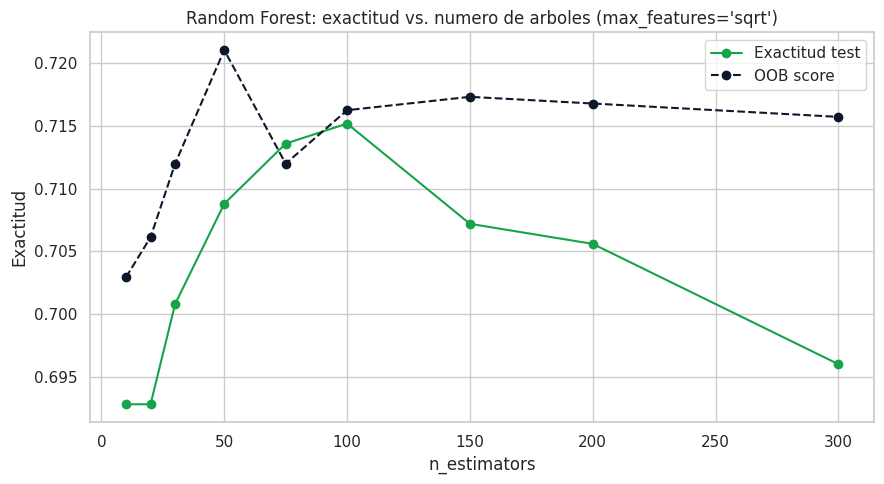

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_estimators_grid, test_accs_rf, marker="o", label="Exactitud test", color="#16a34a")
ax.plot(n_estimators_grid, oob_scores_rf, marker="o", label="OOB score", color="#0f172a", linestyle="--")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Exactitud")
ax.set_title("Random Forest: exactitud vs. numero de arboles (max_features='sqrt')")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** el patrón general de rendimientos decrecientes se repite (como en Bagging), pero con más ruido: el OOB score sube de 0.7029 (`n_estimators=10`) a un máximo de **0.7211** en `n_estimators=50`, y luego oscila entre 0.712 y 0.717 sin una tendencia clara hasta `n_estimators=300`. La exactitud de prueba tiene su máximo en `n_estimators=100` (**0.7152**) pero **no crece de forma monótona** — de hecho baja levemente entre 100 y 300 árboles (0.7152 → 0.6960). Esta falta de monotonía no contradice la teoría (más árboles nunca *aumenta* la varianza esperada del ensamble): es ruido de una sola partición de prueba de 625 filas, el mismo tipo de fluctuación de menos de un punto porcentual que ya se observó en Bagging. La conclusión práctica es la misma que en el Cuaderno 03: más allá de unos 50-100 árboles, seguir aumentando `n_estimators` deja de mejorar el desempeño de forma sistemática y solo aumenta el costo computacional — el techo de exactitud en este dataset lo determina `max_features` (Sección 4) y la información disponible en las variables, no el número de árboles.

---
## 6. Importancia de Características: dos formas de medirla 📊

Una de las mayores ventajas de un Random Forest sobre un árbol individual es que, al perder la interpretabilidad directa de "seguir las ramas" de un único árbol, se gana una forma **agregada y más estable** de medir qué variables importan: la **importancia por impureza** (*Gini importance*, `.feature_importances_`), que promedia sobre todos los árboles cuánto reduce cada variable la impureza cada vez que se usa para dividir, ponderado por cuántas observaciones pasan por esa división.

Esta medida, sin embargo, tiene un **sesgo conocido**: tiende a sobrestimar variables **continuas o de alta cardinalidad** (con muchos valores únicos, y por lo tanto muchos umbrales de corte posibles a probar), frente a variables categóricas con pocas categorías — incluso si estas últimas son más informativas para la predicción real. La alternativa más confiable es la **importancia por permutación** (`sklearn.inspection.permutation_importance`): mide, para cada variable, cuánto **empeora** la exactitud del modelo *ya entrenado* cuando se baraja aleatoriamente esa columna en el conjunto de prueba (rompiendo su relación con `churn` sin volver a entrenar nada) — no depende de cómo se construyeron los árboles, así que no hereda el sesgo de la importancia por impureza.

Para estabilizar ambas estimaciones se usa un Random Forest algo más grande (`n_estimators=200`) que el de las secciones anteriores.

In [41]:
rf_final = RandomForestClassifier(n_estimators=200, max_features="sqrt", oob_score=True, random_state=42)
rf_final.fit(Xtr, ytr)
print(f"Random Forest final (200 arboles, max_features='sqrt') -> train={rf_final.score(Xtr, ytr):.4f}  "
      f"test={rf_final.score(Xte, yte):.4f}  OOB={rf_final.oob_score_:.4f}")

importancia_gini = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nImportancia por impureza (Gini):")
print(importancia_gini)

Random Forest final (200 arboles, max_features='sqrt') -> train=1.0000  test=0.7056  OOB=0.7168

Importancia por impureza (Gini):
cargo_mensual          0.3096
cargos_totales         0.2854
antiguedad_meses       0.2372
tipo_contrato_ord      0.1180
factura_electronica    0.0201
soporte_No             0.0114
soporte_Si             0.0097
soporte_Sin_Internet   0.0086
dtype: float64


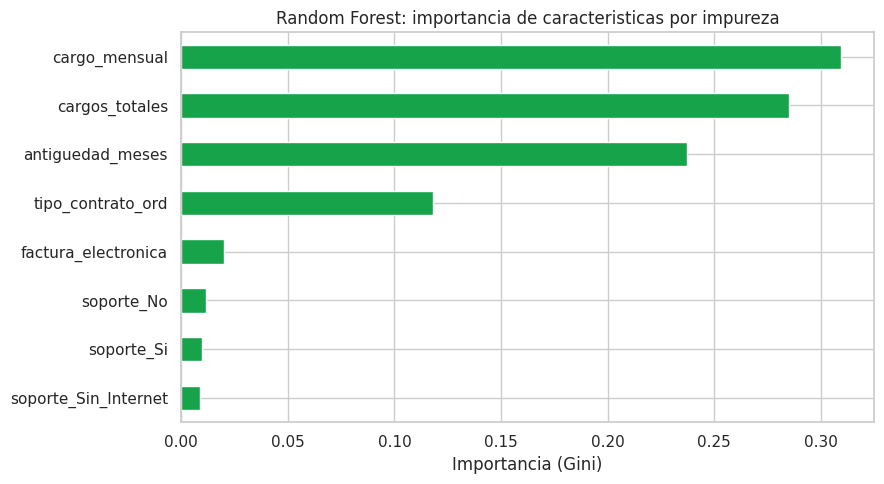

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
importancia_gini.sort_values().plot(kind="barh", ax=ax, color="#16a34a")
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Random Forest: importancia de caracteristicas por impureza")
plt.tight_layout()
plt.show()

**Lectura (importancia por Gini):** según esta medida, las tres variables continuas dominan claramente: `cargo_mensual` (**0.3096**), `cargos_totales` (**0.2854**) y `antiguedad_meses` (**0.2372**) suman más del **83%** de la importancia total, dejando a `tipo_contrato_ord` en un distante cuarto lugar (**0.1180**) — a pesar de que el Cuaderno 00 la había identificado como la variable individualmente más informativa de un único árbol (importancia 0.4790 en ese árbol sin restricciones). Esta discrepancia es exactamente el sesgo que se anticipó arriba: `cargo_mensual`, `cargos_totales` y `antiguedad_meses` son variables continuas con cientos de valores únicos, así que CART tiene muchísimos umbrales candidatos entre los que elegir en cada división — y cuantos más umbrales se prueban, mayor la oportunidad de encontrar por azar una reducción de impureza grande, incluso en variables con menor relación real con `churn`. Además, `cargos_totales` está fuertemente correlacionada con `antiguedad_meses` (correlación de Pearson **0.794**, verificable con `df_prep[feature_cols].corr()`) y con `cargo_mensual` (**0.526**) — información en gran parte redundante que el criterio de impureza reparte entre las tres, inflando la importancia agregada de ese grupo.

### 6.1 Importancia por permutación: la alternativa sin sesgo

In [43]:
perm = permutation_importance(rf_final, Xte, yte, n_repeats=30, random_state=42, scoring="accuracy")
importancia_perm = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
importancia_perm_std = pd.Series(perm.importances_std, index=feature_cols)

print("Importancia por permutacion (caida media de exactitud al barajar cada variable, 30 repeticiones):")
print(importancia_perm)
print("\nDesviacion estandar de las 30 repeticiones:")
print(importancia_perm_std)

Importancia por permutacion (caida media de exactitud al barajar cada variable, 30 repeticiones):
tipo_contrato_ord       0.0419
antiguedad_meses        0.0086
cargo_mensual           0.0060
factura_electronica    -0.0089
soporte_Sin_Internet   -0.0098
soporte_Si             -0.0127
soporte_No             -0.0146
cargos_totales         -0.0234
dtype: float64

Desviacion estandar de las 30 repeticiones:
antiguedad_meses       0.0096
cargo_mensual          0.0131
cargos_totales         0.0114
tipo_contrato_ord      0.0119
factura_electronica    0.0084
soporte_No             0.0072
soporte_Si             0.0081
soporte_Sin_Internet   0.0058
dtype: float64


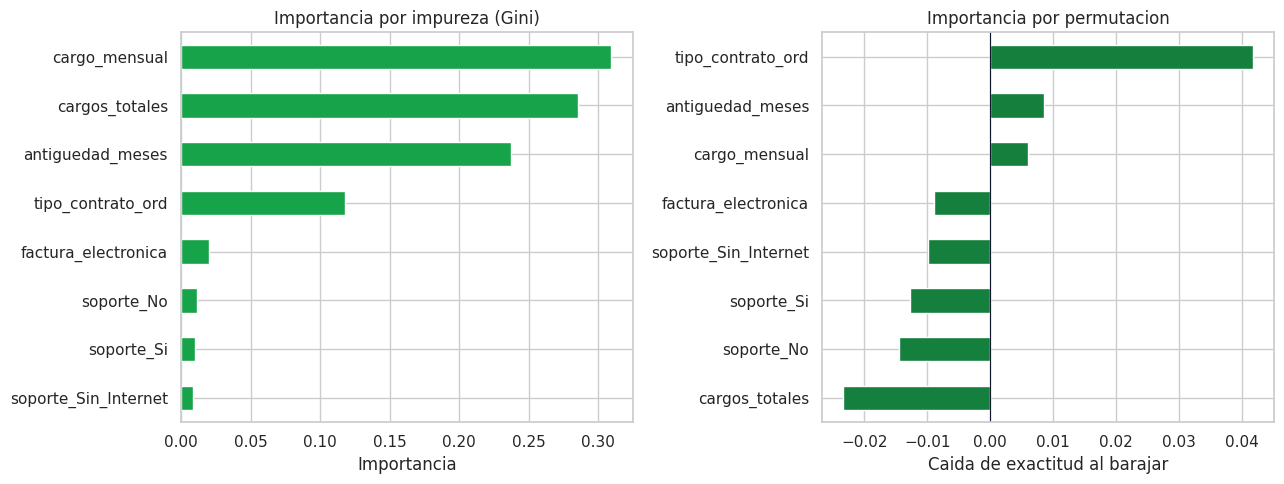

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
importancia_gini.sort_values().plot(kind="barh", ax=axes[0], color="#16a34a")
axes[0].set_title("Importancia por impureza (Gini)")
axes[0].set_xlabel("Importancia")

importancia_perm.sort_values().plot(kind="barh", ax=axes[1], color="#15803d")
axes[1].axvline(0, color="#0f172a", linewidth=0.8)
axes[1].set_title("Importancia por permutacion")
axes[1].set_xlabel("Caida de exactitud al barajar")
plt.tight_layout()
plt.show()

**Lectura (importancia por permutación) — un ranking casi opuesto:** `tipo_contrato_ord` resulta, con enorme diferencia, la variable más importante (**0.0419**: barajarla le cuesta al modelo más de 4 puntos porcentuales de exactitud), seguida muy de lejos por `antiguedad_meses` (0.0086) y `cargo_mensual` (0.0060). Más llamativo aún: `cargos_totales` —la segunda variable más "importante" según Gini— tiene aquí una importancia **negativa** (**-0.0234**): barajarla *no perjudica* la exactitud del modelo en el conjunto de prueba, e incluso la mejora ligeramente en promedio. Esto tiene una explicación coherente con la Sección 6 anterior: `cargos_totales` está altamente correlacionada con `antiguedad_meses` y `cargo_mensual` (0.794 y 0.526), así que su información ya está disponible en esas otras dos columnas — el modelo puede "reconstruir" lo que perdía al barajar `cargos_totales` usando sus variables correlacionadas, y por eso destruir esa columna específica no le cuesta casi nada. Las variables de `soporte_tecnico` y `factura_electronica` tienen importancias por permutación cercanas a cero y comparables en magnitud a su desviación estándar (por ejemplo, `factura_electronica`: -0.0089 ± 0.0084) — indistinguibles de ruido, consistente con su importancia Gini también baja.

**Comparación honesta:** las dos medidas **no son intercambiables** y aquí producen conclusiones de negocio casi opuestas sobre cuál es el factor más importante. La importancia por Gini está inflada por la alta cardinalidad y la redundancia entre las tres variables continuas; la importancia por permutación, calculada directamente sobre la caída de exactitud en datos de prueba reales, es la medida más confiable y **coincide con la conclusión original del Cuaderno 00** (un único árbol sin restricciones): `tipo_contrato_ord` — el tipo de contrato del cliente — es el factor individual más determinante para predecir el abandono. En términos de negocio: **el tipo de contrato (mes a mes vs. uno o dos años) es la señal más confiable de riesgo de abandono**, muy por delante de cuánto paga el cliente o cuánto tiempo lleva — un resultado más útil y más accionable (los contratos son una palanca que la empresa puede ofrecer activamente) que lo que sugeriría, de forma engañosa, la importancia por impureza sin más contexto.

---
## 7. El recorrido completo del Módulo 04, en una tabla 📋

La siguiente tabla resume, con los números reales calculados en cada cuaderno, el recorrido completo: de un único árbol inestable a un bosque de árboles decorrelacionados.

In [45]:
rf_ajustado = RandomForestClassifier(n_estimators=100, max_features=8, oob_score=True, random_state=42).fit(Xtr, ytr)
preds_ajustado = np.array([est.predict(Xte.values) for est in rf_ajustado.estimators_])
corr_ajustado = np.corrcoef(preds_ajustado)
iu2 = np.triu_indices_from(corr_ajustado, k=1)

recorrido = pd.DataFrame({
    "Modelo": ["Arbol sin restricciones (C.00)", "Arbol podado, ccp_alpha=0.001778 (C.02)",
               "Bagging, 50 arboles (C.03)", "Random Forest, max_features='sqrt' (C.04)",
               "Random Forest, max_features=8 (C.04, Sec.4)"],
    "Complejidad": ["901 nodos, prof.25", "21 nodos, prof.6", "50 arboles sin podar",
                     "100 arboles, m=2/division", "100 arboles, m=8/division"],
    "Acc_train": [1.0000, arbol_post_podado.score(Xtr, ytr), bagging.score(Xtr, ytr),
                  rf.score(Xtr, ytr), rf_ajustado.score(Xtr, ytr)],
    "Acc_test": [0.6928, arbol_post_podado.score(Xte, yte), bagging.score(Xte, yte),
                 rf.score(Xte, yte), rf_ajustado.score(Xte, yte)],
    "OOB": [np.nan, np.nan, bagging.oob_score_, rf.oob_score_, rf_ajustado.oob_score_],
    "Corr_entre_arboles": [np.nan, np.nan, 0.3073, correlaciones_rf[iu].mean(), corr_ajustado[iu2].mean()],
    "Interpretabilidad": ["Alta (un arbol) pero inestable", "Muy alta (compacto, visualizable)",
                           "Baja individual, sin importancia agregada", "Baja individual, +feature_importances_",
                           "Baja individual, +feature_importances_"],
})
display(recorrido.round(4))

,Modelo,Complejidad,Acc_train,Acc_test,OOB,Corr_entre_arboles,Interpretabilidad
0,Arbol sin restricciones (C.00),"901 nodos, prof.25",1.0000,0.6928,NaN,NaN,Alta (un arbol) pero inestable
1,"Arbol podado, ccp_alpha=0.001778 (C.02)","21 nodos, prof.6",0.7616,0.7584,NaN,NaN,"Muy alta (compacto, visualizable)"
2,"Bagging, 50 arboles (C.03)",50 arboles sin podar,1.0000,0.7216,0.7136,0.3073,"Baja individual, sin importancia agregada"
3,"Random Forest, max_features='sqrt' (C.04)","100 arboles, m=2/division",1.0000,0.7152,0.7163,0.2883,"Baja individual, +feature_importances_"
4,"Random Forest, max_features=8 (C.04, Sec.4)","100 arboles, m=8/division",1.0000,0.7328,0.7248,0.3135,"Baja individual, +feature_importances_"


**Lectura de la tabla:** el hilo conductor del módulo es una progresión de estrategias contra la **varianza**: primero se restringe un único árbol (poda), luego se promedian muchos árboles complejos (Bagging), y finalmente se fuerza a esos árboles a ser distintos entre sí (Random Forest). Sobre `abandono_clientes_telecom.csv`, ningún ensamble supera a la poda cuidadosa de un único árbol (0.7584): el dataset es pequeño (2500 filas), tiene pocas variables (8) y una señal dominante y relativamente simple (`tipo_contrato_ord`), justo el escenario donde un árbol bien podado ya captura casi toda la estructura explicable, y donde forzar diversidad adicional (Random Forest) cuesta más en fuerza individual de lo que gana en decorrelación. La fila de correlación entre árboles, sin embargo, confirma que el **mecanismo** de Random Forest funciona exactamente como predice la teoría (0.3073 → 0.2883 con `max_features='sqrt'`, y de vuelta a 0.3135 con `max_features=8` — prácticamente igual a Bagging, como cabía esperar cuando $m=p$): la decorrelación es real y medible, incluso cuando en este dataset concreto no se traduce en una ganancia neta de exactitud sobre la mejor poda. En datasets más grandes, con más variables y relaciones más complejas —el escenario típico en la práctica profesional— Random Forest sí suele superar de forma clara tanto a un árbol podado como a Bagging; la honestidad de esta comparación es parte de la lección: **ningún algoritmo es categóricamente superior en todos los datasets**, y la validación empírica (barridos, comparación directa) importa más que aplicar una receta por defecto.

---
## 8. Ejercicio Práctico Guiado: decorrelación con datasets pequeños vs. grandes 📝

**Contexto:** la Sección 3 mostró que, sobre este dataset de $p=8$ variables, `max_features='sqrt'` (m=2) reduce la correlación entre árboles de 0.3073 (Bagging) a 0.2883. La Sección 7 calculó que con `max_features=8` (equivalente a usar todas las variables) esa correlación **vuelve a subir**. Vas a verificar ese efecto de forma más completa, barriendo la correlación entre árboles para varios valores de `max_features` y confirmando la relación entre `max_features` y el porcentaje de árboles que usan `tipo_contrato_ord` en la raíz.

**Tu misión:**
1. Para cada valor de `max_features` en `[1, 2, 3, 4, 6, 8]`, entrena un `RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42)` sobre `Xtr, ytr`.
2. Para cada uno, calcula la correlación promedio entre las predicciones de pares de árboles sobre `Xte` (como en la Sección 3) y el porcentaje de árboles que eligen `tipo_contrato_ord` como variable de la raíz.
3. Construye una tabla (`pd.DataFrame`) con columnas `max_features`, `correlacion_promedio` y `pct_raiz_tipo_contrato`, ordenada por `max_features`.
4. Interpreta la tendencia: ¿la correlación entre árboles sube o baja a medida que crece `max_features`? ¿Coincide con lo que predice la teoría de la Sección 1?

In [46]:
### TU CÓDIGO AQUÍ ###
# 1-2. Para cada max_features, entrena un RF y calcula correlacion promedio + % raiz tipo_contrato_ord
resultados_ejercicio = []
mf_valores = [1, 2, 3, 4, 6, 8]

for mf in mf_valores:
    modelo = None  # RandomForestClassifier(...)
    # correlacion promedio entre pares de arboles sobre Xte
    corr_prom = None
    # porcentaje de arboles con tipo_contrato_ord en la raiz
    pct_raiz = None
    resultados_ejercicio.append({"max_features": mf, "correlacion_promedio": corr_prom, "pct_raiz_tipo_contrato": pct_raiz})

# 3. Tabla final
tabla_ejercicio = None
print(tabla_ejercicio)

# 4. Interpretacion: escribe tu conclusion como comentario aqui

None


<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
resultados_ejercicio = []
mf_valores = [1, 2, 3, 4, 6, 8]

for mf in mf_valores:
    modelo = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42).fit(Xtr, ytr)

    preds = np.array([est.predict(Xte.values) for est in modelo.estimators_])
    corr = np.corrcoef(preds)
    iu_ej = np.triu_indices_from(corr, k=1)
    corr_prom = corr[iu_ej].mean()

    raices = [feature_cols[est.tree_.feature[0]] for est in modelo.estimators_]
    pct_raiz = (Counter(raices)["tipo_contrato_ord"] / len(modelo.estimators_)) * 100

    resultados_ejercicio.append({"max_features": mf, "correlacion_promedio": corr_prom, "pct_raiz_tipo_contrato": pct_raiz})

tabla_ejercicio = pd.DataFrame(resultados_ejercicio)
print(tabla_ejercicio.round(4))
```

Resultado real:

| max_features | correlacion_promedio | pct_raiz_tipo_contrato |
|---|---|---|
| 1 | 0.2751 | 11.0% |
| 2 (= 'sqrt') | 0.2883 | 23.0% |
| 3 (= 'log2') | 0.2897 | 36.0% |
| 4 | 0.2971 | 50.0% |
| 6 | 0.3103 | 72.0% |
| 8 (= todas)  | 0.3135 | 100.0% |

**Interpretación:** la tendencia confirma exactamente la teoría de la Sección 1, de forma perfectamente monótona en ambas columnas: a medida que `max_features` crece de 1 a 8, tanto la correlación promedio entre árboles (0.2751 → 0.3135) como el porcentaje de árboles que usan `tipo_contrato_ord` en la raíz (11% → 100%) **aumentan sin excepción**. Con `max_features=1` (la restricción más agresiva posible) la correlación es la más baja del barrido y solo el 11% de los árboles usa esa variable en la raíz; con `max_features=8` (todas las variables, equivalente a Bagging) la correlación alcanza su máximo (0.3135, prácticamente igual a la de Bagging en el Cuaderno 03, 0.3073) y el 100% de los árboles coincide en la raíz, exactamente el síntoma que motivó este cuaderno. Esta relación monótona es la evidencia más directa de que Random Forest hace exactamente lo que promete: cuanto más se restringe el número de variables candidatas por división, más decorrelacionados quedan los árboles — la pregunta abierta por la Sección 4 (si eso se traduce en mejor exactitud) depende del dataset, pero el mecanismo de decorrelación en sí mismo es robusto, monótono y verificable.

</details>

---
## 9. Resumen Ejecutivo del Módulo 04 🎓

Los cinco cuadernos de este módulo cuentan una sola historia, atacando el mismo problema —la **alta varianza** de los árboles de decisión— desde ángulos cada vez más sofisticados:

1. **Cuaderno 00 (Fundamentos y CART):** un árbol de decisión particiona el espacio de forma binaria y recursiva, produciendo reglas interpretables — pero sin restricciones, memoriza los datos de entrenamiento (train=1.0000) y generaliza mal (test=0.6928): son modelos de **varianza alta**.
2. **Cuaderno 01 (Criterios de división):** Gini, Entropía y Reducción de Varianza son las funciones que CART usa internamente para decidir *cómo* dividir cada nodo — el mecanismo, no la cura, del problema de varianza.
3. **Cuaderno 02 (Poda):** ataca la varianza **restringiendo un único árbol**, con pre-poda (`max_depth=4`, test=0.7600) o post-poda (`ccp_alpha=0.001778`, test=0.7584) — la mejor exactitud de prueba de todo el módulo sobre este dataset, con un árbol compacto y visualizable.
4. **Cuaderno 03 (Bagging):** ataca la varianza desde el ángulo opuesto — en lugar de restringir un árbol, **promedia muchos árboles complejos** entrenados sobre muestras bootstrap distintas (test=0.7216, OOB=0.7136) — pero descubre que los árboles del ensamble están lejos de ser independientes (correlación 0.3073, 100% coinciden en la raíz), limitando la ganancia.
5. **Cuaderno 04 (Random Forests, este cuaderno):** resuelve la limitación exacta del Cuaderno 03 añadiendo aleatoriedad también en las **variables** consideradas en cada división — decorrelacionando los árboles de forma verificable (correlación 0.3073 → 0.2883, raíz dominante 100% → 23%) y ganando, a cambio, una forma agregada y más robusta de medir qué variables importan (`feature_importances_` y, más confiable, `permutation_importance`).

**La lección más importante no es que Random Forest "gane" siempre** — en `abandono_clientes_telecom.csv`, con solo 8 variables y una señal dominante simple, la mejor poda de un único árbol (0.7584) iguala o supera a todos los ensambles probados. La lección es **metodológica**: cada técnica de este módulo resuelve un problema real y verificable (sobreajuste, varianza, correlación entre modelos), y la forma correcta de decidir cuál usar en un problema nuevo es **medir**, con barridos de hiperparámetros y comparaciones honestas sobre datos de prueba reales — no asumir que el algoritmo más sofisticado es automáticamente el mejor. El **Taller Práctico Evaluativo** (`homeworks/04_Arboles_Bosques_Hands_On.ipynb`) pone en práctica exactamente ese proceso completo, de principio a fin, sobre este mismo problema de negocio.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Árboles y Bosques Aleatorios</i>
  </p>
</div>